# H-CAST Hierarchy Variant Comparison

This notebook mirrors `hcast_analysis.ipynb`, but compares **H-CAST hierarchy variants**:

- `H-CAST` (baseline run path in `RUN_SPECS`)
- `H-CAST + soft top-down KL`
- `H-CAST + design1 (temperature=10)`

It includes:
- validation curves for `FPA`, `wAP`, `TICE`, and `AHD`,
- training loss comparison (aggregate + per-level losses),
- per-level validation accuracy curves,
- a final test comparison table with deltas and a quick summary.

Update `RUN_SPECS` in the configuration cell to match your run directories.


In [17]:
from pathlib import Path
import json
import re

import numpy as np
import yaml
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

def resolve_project_root():
    cwd = Path.cwd().resolve()
    candidates = [cwd, cwd.parent]
    for candidate in candidates:
        if (candidate / 'configs').exists():
            return candidate
    return cwd


PROJECT_ROOT = resolve_project_root()
OUTPUTS_ROOT = Path('/scratch/g.saggini1/outputs')
print(f'Using project root: {PROJECT_ROOT}')


Using project root: /home/g.saggini1/lexicographic_deep_learning_detailed_study


In [18]:
_ACC_LEVEL_PATTERN = re.compile(r'^acc_level_(\\d+)$')
_ACC_LEVEL_TOPDOWN_PATTERN = re.compile(r'^acc_level_topdown_(\\d+)$')
_ACC_LEVEL_INDEPENDENT_PATTERN = re.compile(r'^acc_level_independent_(\\d+)$')


def _as_float_dict(metrics):
    out = {}
    if not isinstance(metrics, dict):
        return out
    for key, value in metrics.items():
        try:
            out[str(key)] = float(value)
        except (TypeError, ValueError):
            continue
    return out


def normalize_metrics(metrics):
    """Normalize metric key variants from older/newer logs into one schema."""
    out = _as_float_dict(metrics)

    # Weighted AP aliases
    if 'weighted_ap_topdown' not in out:
        if 'weighted_ap' in out:
            out['weighted_ap_topdown'] = out['weighted_ap']
        elif 'weighted_ap_independent' in out:
            out['weighted_ap_topdown'] = out['weighted_ap_independent']
    if 'weighted_ap_independent' not in out and 'weighted_ap_topdown' in out:
        out['weighted_ap_independent'] = out['weighted_ap_topdown']

    # FPA aliases
    if 'fpa_topdown' not in out:
        if 'fpa' in out:
            out['fpa_topdown'] = out['fpa']
        elif 'fpa_independent' in out:
            out['fpa_topdown'] = out['fpa_independent']
    if 'fpa_independent' not in out and 'fpa_topdown' in out:
        out['fpa_independent'] = out['fpa_topdown']

    # TICE aliases
    if 'tice_topdown' not in out:
        if 'tice' in out:
            out['tice_topdown'] = out['tice']
        elif 'tice_independent' in out:
            out['tice_topdown'] = out['tice_independent']
    if 'tice_independent' not in out and 'tice_topdown' in out:
        out['tice_independent'] = out['tice_topdown']

    # AHD aliases
    if 'ahd_topdown' not in out:
        if 'ahd' in out:
            out['ahd_topdown'] = out['ahd']
        elif 'ahd_independent' in out:
            out['ahd_topdown'] = out['ahd_independent']
    if 'ahd_independent' not in out and 'ahd_topdown' in out:
        out['ahd_independent'] = out['ahd_topdown']

    # Legacy per-level accuracy aliases (acc_level_{i})
    for key, value in list(out.items()):
        match = _ACC_LEVEL_PATTERN.match(key)
        if match:
            level_idx = int(match.group(1))
            out.setdefault(f'acc_level_independent_{level_idx}', value)
            out.setdefault(f'acc_level_topdown_{level_idx}', value)

    # Fill missing top-down/independent level metrics from each other when only one exists.
    level_ids = set()
    for key in list(out.keys()):
        match = _ACC_LEVEL_TOPDOWN_PATTERN.match(key)
        if match:
            level_ids.add(int(match.group(1)))
            continue
        match = _ACC_LEVEL_INDEPENDENT_PATTERN.match(key)
        if match:
            level_ids.add(int(match.group(1)))

    for level_idx in level_ids:
        topdown_key = f'acc_level_topdown_{level_idx}'
        independent_key = f'acc_level_independent_{level_idx}'
        if topdown_key not in out and independent_key in out:
            out[topdown_key] = out[independent_key]
        if independent_key not in out and topdown_key in out:
            out[independent_key] = out[topdown_key]

    return out


def load_jsonl_events(path):
    events = []
    with Path(path).open('r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if line:
                events.append(json.loads(line))
    return events


def load_yaml(path):
    with Path(path).open('r', encoding='utf-8') as f:
        return yaml.safe_load(f)


def metric_for_best(metrics):
    """Mirror train.utils.metric_for_best for consistent best-epoch selection."""
    m = normalize_metrics(metrics)

    has_fpa = 'fpa_topdown' in m
    has_tice = 'tice_topdown' in m
    has_wap = 'weighted_ap_topdown' in m

    if has_fpa or has_tice or has_wap:
        fpa = float(m.get('fpa_topdown', 0.0))
        neg_tice = -float(m.get('tice_topdown', 1.0))
        wap = float(m.get('weighted_ap_topdown', 0.0))
        return float(fpa + 1e-3 * neg_tice + 1e-6 * wap)

    topdown_keys = [
        key
        for key in m
        if key.startswith('acc_level_topdown_') and key.rsplit('_', 1)[-1].isdigit()
    ]
    independent_keys = [
        key
        for key in m
        if key.startswith('acc_level_independent_') and key.rsplit('_', 1)[-1].isdigit()
    ]
    deepest = topdown_keys or independent_keys
    if not deepest:
        return float(m.get('fpa_topdown', 0.0))

    deepest_key = max(deepest, key=lambda key: int(key.rsplit('_', 1)[-1]))
    primary = float(m.get(deepest_key, 0.0))
    tie = float(m.get('fpa_topdown', 0.0))
    return float(primary + 1e-3 * tie)


def parse_run(run_dir):
    run_path = Path(run_dir)
    events = load_jsonl_events(run_path / 'run_log.jsonl')
    epoch_events = [event for event in events if event.get('event') == 'epoch']

    for event in epoch_events:
        event['train_metrics_norm'] = normalize_metrics(event.get('train_metrics', {}))
        event['val_metrics_norm'] = normalize_metrics(event.get('val_metrics', {}))
        event['rank_score'] = metric_for_best(event['val_metrics_norm'])

    test_events = [event for event in events if event.get('event') == 'test']
    test_event = test_events[-1] if test_events else {}
    test_metrics = normalize_metrics(test_event.get('test_metrics', {}))

    test_metrics_yaml = {}
    test_yaml_path = run_path / 'test_metrics.yaml'
    if test_yaml_path.exists():
        test_metrics_yaml = load_yaml(test_yaml_path) or {}
        if not test_metrics:
            test_metrics = normalize_metrics(test_metrics_yaml.get('test_metrics', {}))

    level_names = []
    cfg_path = run_path / 'config_resolved.yaml'
    if cfg_path.exists():
        cfg = load_yaml(cfg_path) or {}
        level_names = list(cfg.get('dataset', {}).get('levels', []))

    best_epoch_event = None
    if epoch_events:
        best_idx = int(np.argmax([event['rank_score'] for event in epoch_events]))
        best_epoch_event = epoch_events[best_idx]

    return {
        'run_dir': run_path,
        'events': events,
        'epoch_events': epoch_events,
        'test_event': test_event,
        'test_metrics': test_metrics,
        'test_metrics_yaml': test_metrics_yaml,
        'level_names': level_names,
        'best_epoch_event': best_epoch_event,
    }


def get_metric_series(epoch_events, metric_key):
    epochs = [int(event['epoch']) for event in epoch_events]
    values = [float(event['val_metrics_norm'].get(metric_key, np.nan)) for event in epoch_events]
    return np.array(epochs, dtype=np.int32), np.array(values, dtype=np.float64)


def get_level_label(level_idx, run_data):
    names = run_data.get('level_names') or []
    if level_idx < len(names):
        return str(names[level_idx])
    return f'L{level_idx}'


In [19]:
# -------- Configuration --------
RUN_SPECS = [
    {
        'label': 'H-CAST + 0.2 mixup',
        'run_dir': OUTPUTS_ROOT / 'hcast_cifar100_0.2mix',
        'color': '#2ca02c',
    },
    {
        'label': 'H-CAST + Design1 (T=10)',
        'run_dir': OUTPUTS_ROOT / 'hcast_design1_cifar100_temp10',
        'color': '#ff7f0e',
    },
    {
        'label': 'H-CAST + Soft Topdown + no gated logits',
        'run_dir': OUTPUTS_ROOT / 'hcast_soft_topdown_cifar100_nogated',
        'color': "#9022ab",
    },
    {
        'label': 'H-CAST + Soft Topdown + 0.2 mixup',
        'run_dir': OUTPUTS_ROOT / 'hcast_soft_topdown_cifar100_0.2mixup',
        'color': "#7180dc",
    },
]

ALLOW_MISSING_RUNS = True

RUNS = []
missing_runs = []
for run in RUN_SPECS:
    run_dir = Path(run['run_dir'])
    if not (run_dir / 'run_log.jsonl').exists():
        missing_runs.append(run)
        continue
    RUNS.append({
        'label': run['label'],
        'run_dir': run_dir,
        'color': run['color'],
    })

if missing_runs:
    print('Missing run directories (not loaded):')
    for run in missing_runs:
        print(f"  - {run['label']}: {run['run_dir']}")

if not RUNS:
    raise ValueError('No runs found. Check RUN_SPECS paths.')

if len(RUNS) < len(RUN_SPECS) and not ALLOW_MISSING_RUNS:
    raise ValueError('Some configured runs are missing and ALLOW_MISSING_RUNS=False.')

run_data_list = []
for run in RUNS:
    parsed = parse_run(run['run_dir'])
    parsed.update(run)

    cfg_path = parsed['run_dir'] / 'config_resolved.yaml'
    variant_name = 'baseline'
    if cfg_path.exists():
        cfg = load_yaml(cfg_path) or {}
        model_cfg = cfg.get('model', {})
        tags = []
        design1_cfg = model_cfg.get('design1', {})
        if bool(design1_cfg.get('enabled', False)):
            design1_temp = design1_cfg.get('temperature', 'n/a')
            tags.append(f"design1 (temp={design1_temp})")
        soft_topdown_cfg = model_cfg.get('soft_topdown', {})
        if bool(soft_topdown_cfg.get('enabled', False)):
            use_gated = bool(soft_topdown_cfg.get('use_gated_logits', True))
            tags.append(f"soft-topdown (gated={use_gated})")
        if tags:
            variant_name = ' + '.join(tags)

    parsed['variant_name'] = variant_name
    run_data_list.append(parsed)

for run_data in run_data_list:
    epoch_count = len(run_data['epoch_events'])
    best_epoch = run_data['best_epoch_event']['epoch'] if run_data['best_epoch_event'] else None
    best_score = run_data['best_epoch_event']['rank_score'] if run_data['best_epoch_event'] else None
    print(
        f"{run_data['label']} ({run_data['variant_name']}): "
        f"epochs={epoch_count}, best_epoch={best_epoch}, best_score={best_score}"
    )


H-CAST + 0.2 mixup (baseline): epochs=100, best_epoch=98, best_score=0.7545906226959229
H-CAST + Design1 (T=10) (design1 (temp=10.0)): epochs=100, best_epoch=100, best_score=0.741114048248291
H-CAST + Soft Topdown + no gated logits (soft-topdown (gated=False)): epochs=89, best_epoch=88, best_score=0.7431648320983887
H-CAST + Soft Topdown + 0.2 mixup (soft-topdown (gated=True)): epochs=100, best_epoch=100, best_score=0.7459968650909423


## H-CAST Hierarchy Variant Comparison: Validation Curves

Each panel overlays both decoding modes on the **same axes**:

- color = run variant
- line style = mode (`topdown` solid, `independent` dashed)

Metrics shown: `FPA`, `wAP`, `TICE`, `AHD`.


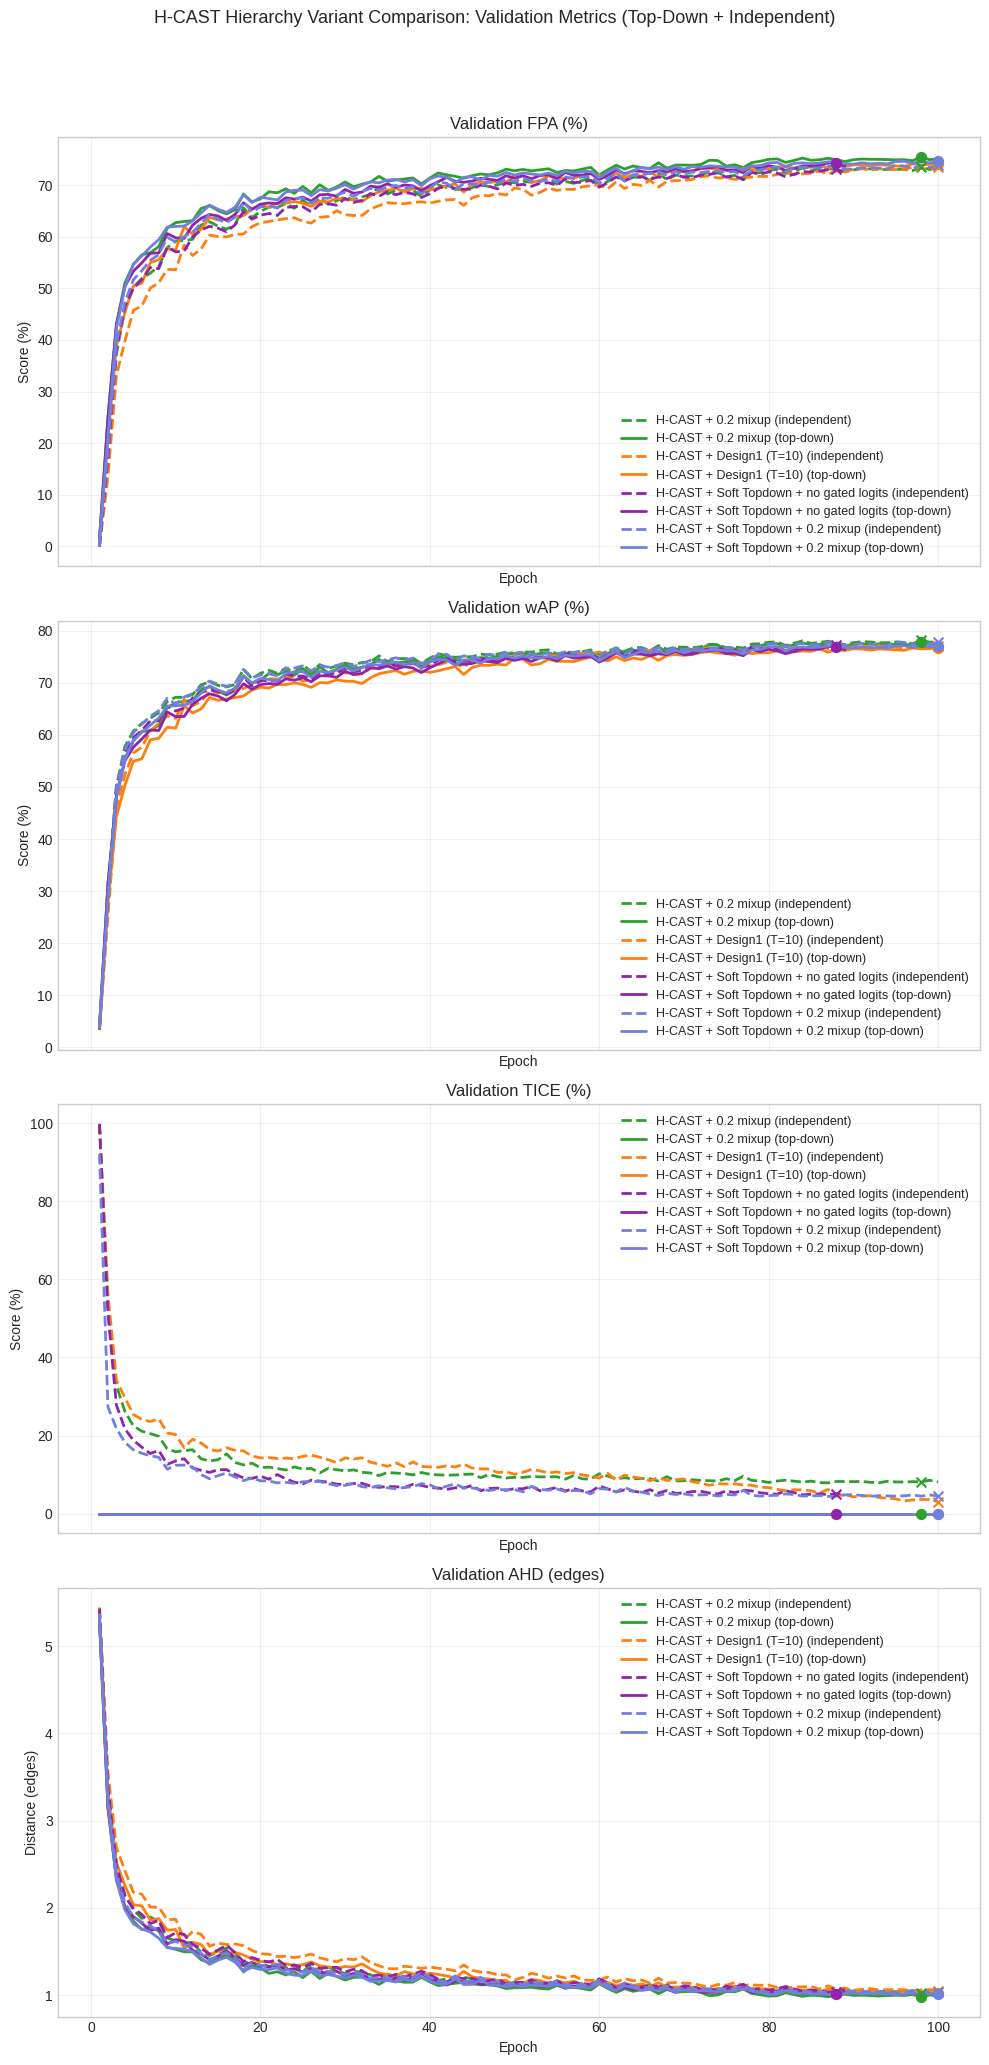

In [20]:
metric_families = [
    ('fpa', 'Validation FPA (%)', True),
    ('weighted_ap', 'Validation wAP (%)', True),
    ('tice', 'Validation TICE (%)', True),
    ('ahd', 'Validation AHD (edges)', False),
]
mode_specs = [
    ('independent', '--', 'independent', 'x'),
    ('topdown', '-', 'top-down', 'o'),
]

fig, axes = plt.subplots(len(metric_families), 1, figsize=(10, 5 * len(metric_families)), sharex=True)
if len(metric_families) == 1:
    axes = [axes]

for ax, (metric_prefix, metric_title, is_percent) in zip(axes, metric_families):
    for run_data in run_data_list:
        for mode_key, line_style, mode_label, marker in mode_specs:
            metric_key = f'{metric_prefix}_{mode_key}'
            epochs, values = get_metric_series(run_data['epoch_events'], metric_key)
            plot_values = values * 100.0 if is_percent else values
            ax.plot(
                epochs,
                plot_values,
                label=f"{run_data['label']} ({mode_label})",
                color=run_data['color'],
                linestyle=line_style,
                linewidth=2.0,
            )

            best_event = run_data['best_epoch_event']
            if best_event is not None:
                best_value = float(best_event['val_metrics_norm'].get(metric_key, np.nan))
                if np.isfinite(best_value):
                    best_plot_value = best_value * 100.0 if is_percent else best_value
                    ax.scatter(
                        [best_event['epoch']],
                        [best_plot_value],
                        color=run_data['color'],
                        marker=marker,
                        s=50,
                        zorder=4,
                    )

    ax.set_title(metric_title)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Score (%)' if is_percent else 'Distance (edges)')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)

plt.suptitle('H-CAST Hierarchy Variant Comparison: Validation Metrics (Top-Down + Independent)', y=1.03, fontsize=13)
plt.tight_layout()
plt.show()


Interpretation note:
- For `FPA` and `wAP`, higher is better; for `TICE`, lower is better.
- Compare solid vs dashed lines of the same color to isolate hierarchy-enforcement effects for one run.
- Compare colors at the same line style to compare runs under the same decoding mode.

## Training Loss Comparison

This section compares training losses between runs for both aggregate losses (`total`, `level_ce`, `gk_loss`, `soft_topdown_kl`) and per-level losses (`loss_level_*`).

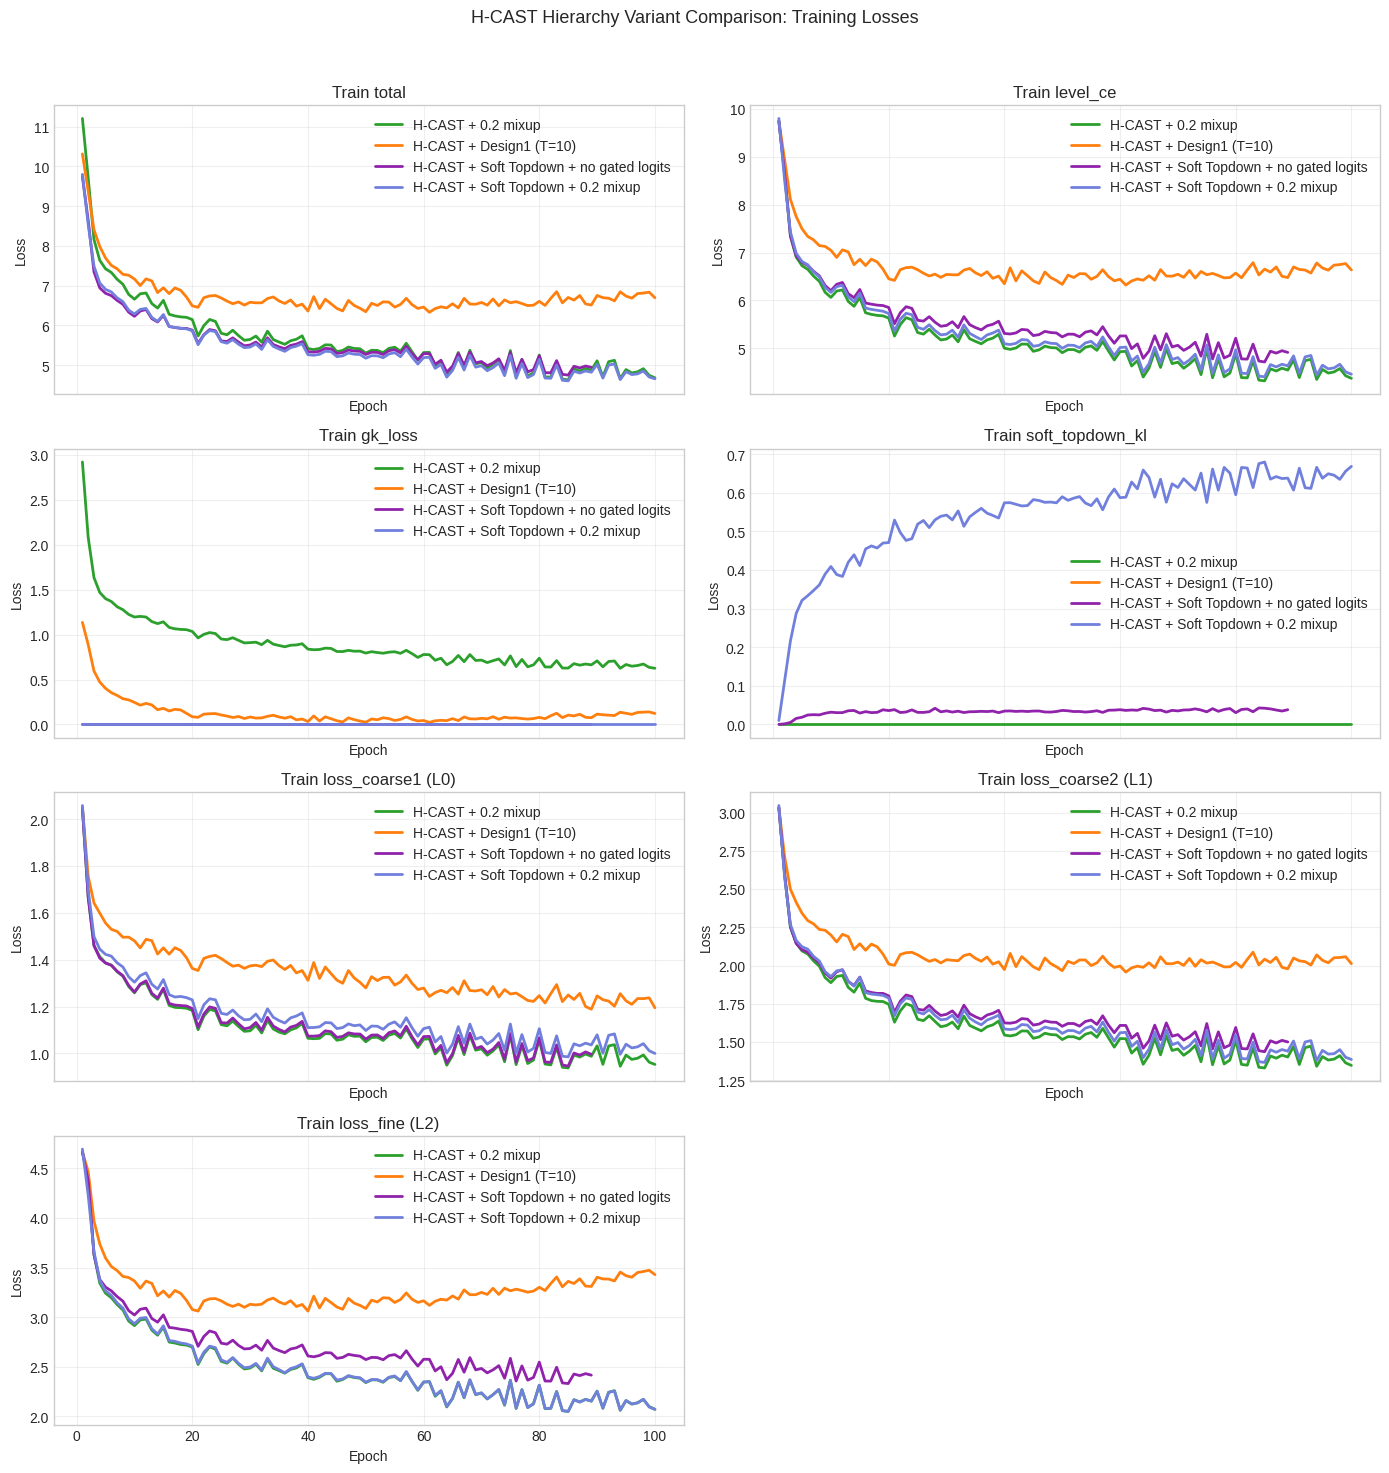

In [21]:
def get_train_loss_series(epoch_events, loss_key):
    epochs = [int(event['epoch']) for event in epoch_events]
    values = [float(event.get('train_losses', {}).get(loss_key, np.nan)) for event in epoch_events]
    return np.array(epochs, dtype=np.int32), np.array(values, dtype=np.float64)

aggregate_loss_keys = ['total', 'level_ce', 'gk_loss', 'soft_topdown_kl']
level_loss_ids = sorted({
    int(key.rsplit('_', 1)[-1])
    for run_data in run_data_list
    for event in run_data['epoch_events']
    for key in event.get('train_losses', {}).keys()
    if key.startswith('loss_level_') and key.rsplit('_', 1)[-1].isdigit()
})

metric_specs = [(key, key) for key in aggregate_loss_keys]
for level_idx in level_loss_ids:
    level_name = get_level_label(level_idx, run_data_list[0])
    metric_specs.append((f'loss_level_{level_idx}', f'loss_{level_name} (L{level_idx})'))

n_metrics = len(metric_specs)
ncols = 2
nrows = int(np.ceil(n_metrics / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 3.6 * nrows), sharex=True)
axes = np.array(axes).reshape(-1)

for ax, (metric_key, metric_title) in zip(axes, metric_specs):
    for run_data in run_data_list:
        epochs, values = get_train_loss_series(run_data['epoch_events'], metric_key)
        ax.plot(
            epochs,
            values,
            label=run_data['label'],
            color=run_data['color'],
            linewidth=2.0,
        )
    ax.set_title(f'Train {metric_title}')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.grid(True, alpha=0.3)
    ax.legend()

for ax in axes[n_metrics:]:
    ax.axis('off')

plt.suptitle('H-CAST Hierarchy Variant Comparison: Training Losses', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()


Interpretation note:
- Lower is better for all loss curves.
- Compare `total` first for optimization behavior, then `loss_level_*` to see where depth-specific training differs.
- If one run has consistently lower shallow-level loss but much higher deep-level loss, expect weaker fine-grained accuracy and path metrics.

## Per-Level Validation Accuracy (Top-Down and Independent)

Each level plot overlays both modes on the same axes:
- color = run
- line style = mode (`topdown` solid, `independent` dashed).

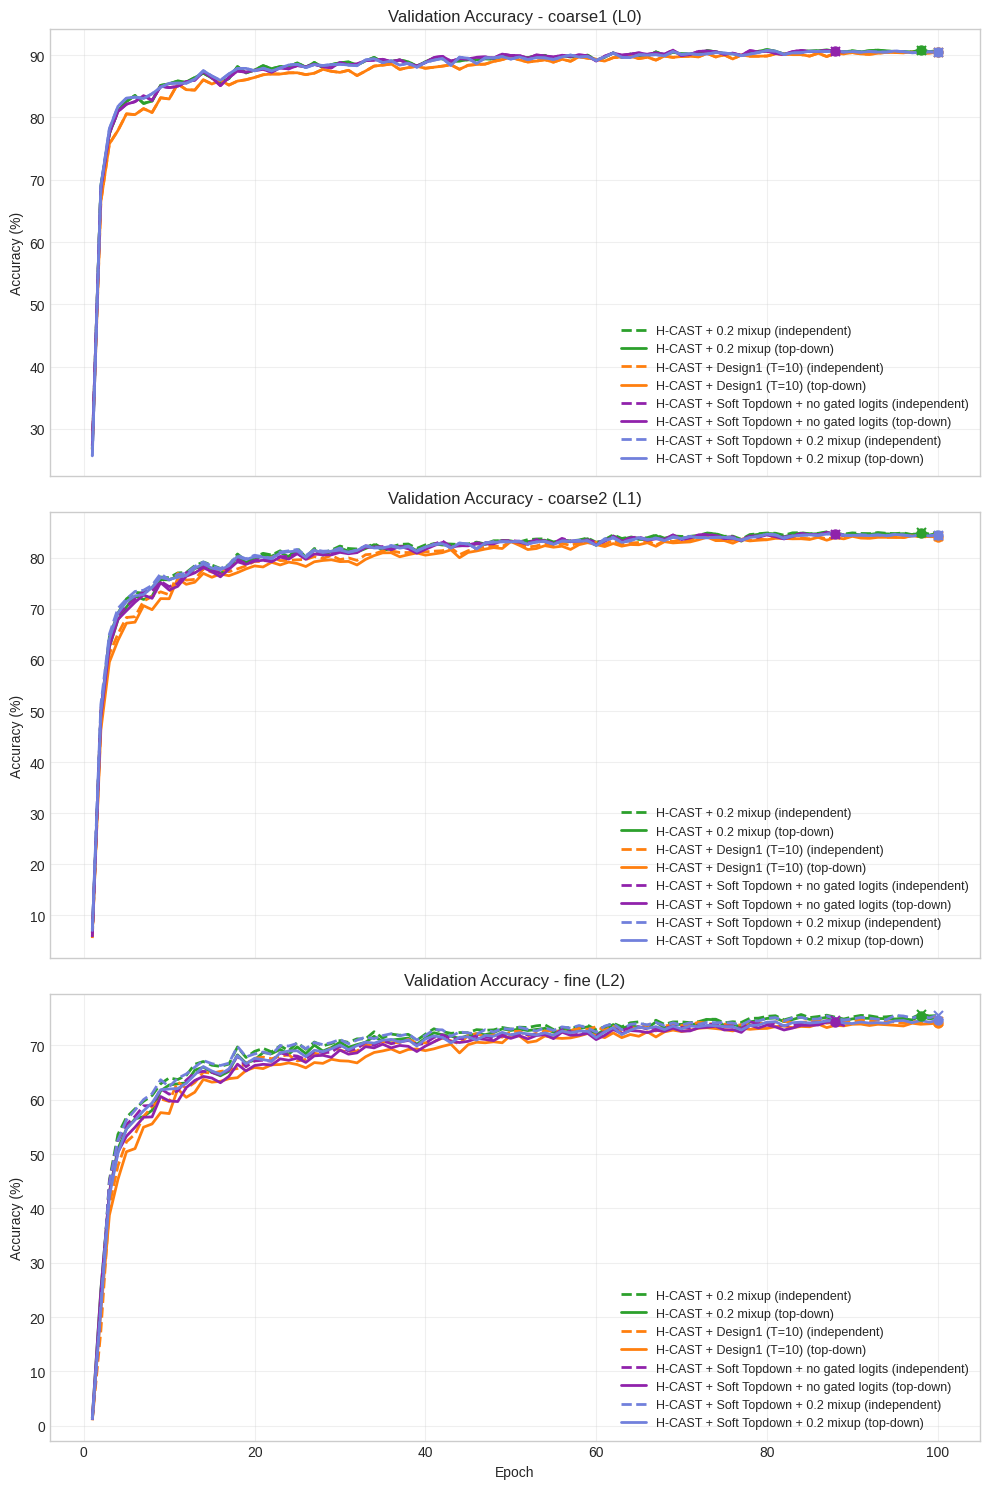

In [22]:
all_level_ids = sorted({
    int(key.rsplit('_', 1)[-1])
    for run_data in run_data_list
    for event in run_data['epoch_events']
    for key in event['val_metrics_norm'].keys()
    if (
        (key.startswith('acc_level_topdown_') or key.startswith('acc_level_independent_'))
        and key.rsplit('_', 1)[-1].isdigit()
    )
})

if not all_level_ids:
    raise ValueError('No per-level validation accuracy metrics found.')

fig, axes = plt.subplots(len(all_level_ids), 1, figsize=(10, 5 * len(all_level_ids)), sharex=True)
if len(all_level_ids) == 1:
    axes = [axes]

mode_specs = [
    ('independent', '--', 'independent', 'x'),
    ('topdown', '-', 'top-down', 'o'),
]

for ax, level_idx in zip(axes, all_level_ids):
    for run_data in run_data_list:
        level_label = get_level_label(level_idx, run_data)
        for mode_key, line_style, mode_label, marker in mode_specs:
            metric_key = f'acc_level_{mode_key}_{level_idx}'
            epochs, values = get_metric_series(run_data['epoch_events'], metric_key)
            ax.plot(
                epochs,
                values * 100.0,
                label=f"{run_data['label']} ({mode_label})",
                color=run_data['color'],
                linestyle=line_style,
                linewidth=2.0,
            )

            best_event = run_data['best_epoch_event']
            if best_event is not None:
                best_value = float(best_event['val_metrics_norm'].get(metric_key, np.nan))
                if np.isfinite(best_value):
                    ax.scatter(
                        [best_event['epoch']],
                        [best_value * 100.0],
                        color=run_data['color'],
                        marker=marker,
                        s=42,
                        zorder=4,
                    )

    ax.set_title(f'Validation Accuracy - {level_label} (L{level_idx})')
    ax.set_ylabel('Accuracy (%)')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)

axes[-1].set_xlabel('Epoch')
plt.tight_layout()
plt.show()


Interpretation note:
- In each subplot, solid vs dashed of the same color gives the top-down penalty/gain for that run.
- Across colors, you can compare runs within the same decoding mode by matching line style.
- Larger gaps at deeper levels usually have the strongest impact on final path metrics.

## Final Test Comparison Table

The table compares key test metrics for all loaded runs and reports deltas versus the first loaded run (typically `H-CAST`).


In [23]:
if not run_data_list:
    raise ValueError('No runs available.')

base = run_data_list[0]
comparisons = run_data_list[1:]

metric_rows = [
    ('fpa_independent', 'FPA independent'),
    ('fpa_topdown', 'FPA top-down'),
    ('weighted_ap_independent', 'wAP independent'),
    ('weighted_ap_topdown', 'wAP top-down'),
    ('tice_independent', 'TICE independent'),
    ('tice_topdown', 'TICE top-down'),
    ('ahd_independent', 'AHD independent'),
    ('ahd_topdown', 'AHD top-down'),
]

for level_idx in all_level_ids:
    level_label = get_level_label(level_idx, base)
    metric_rows.append((f'acc_level_independent_{level_idx}', f'Acc independent {level_label} (L{level_idx})'))
    metric_rows.append((f'acc_level_topdown_{level_idx}', f'Acc top-down {level_label} (L{level_idx})'))


def fmt_pct(x):
    if x is None or not np.isfinite(x):
        return 'n/a'
    return f'{100.0 * x:.2f}%'


def fmt_delta_pp(x):
    if x is None or not np.isfinite(x):
        return 'n/a'
    sign = '+' if x >= 0 else ''
    return f'{sign}{100.0 * x:.2f} pp'


def fmt_edges(x):
    if x is None or not np.isfinite(x):
        return 'n/a'
    return f'{x:.3f}'


def fmt_delta_edges(x):
    if x is None or not np.isfinite(x):
        return 'n/a'
    sign = '+' if x >= 0 else ''
    return f'{sign}{x:.3f}'


header = f"{'Metric':<40}{base['label']:>16}"
for comp in comparisons:
    header += f"{comp['label']:>20}{'Delta vs base':>18}"
print(header)
print('-' * len(header))

for metric_key, metric_name in metric_rows:
    base_value = float(base['test_metrics'].get(metric_key, np.nan))
    is_distance_metric = metric_key.startswith('ahd_')
    base_fmt = fmt_edges(base_value) if is_distance_metric else fmt_pct(base_value)
    row = f"{metric_name:<40}{base_fmt:>16}"
    for comp in comparisons:
        comp_value = float(comp['test_metrics'].get(metric_key, np.nan))
        delta_value = comp_value - base_value if np.isfinite(base_value) and np.isfinite(comp_value) else np.nan
        comp_fmt = fmt_edges(comp_value) if is_distance_metric else fmt_pct(comp_value)
        delta_fmt = fmt_delta_edges(delta_value) if is_distance_metric else fmt_delta_pp(delta_value)
        row += f"{comp_fmt:>20}{delta_fmt:>18}"
    print(row)

if not comparisons:
    print('\nOnly one run is loaded, so no delta columns are shown.')


Metric                                  H-CAST + 0.2 mixupH-CAST + Design1 (T=10)     Delta vs baseH-CAST + Soft Topdown + no gated logits     Delta vs baseH-CAST + Soft Topdown + 0.2 mixup     Delta vs base
---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
FPA independent                                   72.56%              72.56%          +0.00 pp                 n/a               n/a              72.90%          +0.34 pp
FPA top-down                                      74.28%              73.30%          -0.98 pp                 n/a               n/a              73.98%          -0.29 pp
wAP independent                                   77.48%              76.36%          -1.12 pp                 n/a               n/a              77.08%          -0.40 pp
wAP top-down                                      76.94%              7

Interpretation note:
- Positive delta means the comparison run is higher than baseline for that metric; for `tice_*`, lower is better, so negative delta is desirable.
- Use this table to measure the effect of each hierarchy variant against the chosen baseline (`H-CAST`).
- Compare independent vs top-down rows per level to quantify how hierarchy constraints change across variants.


In [24]:
print('Quick summary')
print('------------')
for run_data in run_data_list:
    best = run_data['best_epoch_event']
    if best is None:
        continue
    best_fpa_ind = best['val_metrics_norm'].get('fpa_independent', np.nan)
    best_fpa_td = best['val_metrics_norm'].get('fpa_topdown', np.nan)
    best_wap_ind = best['val_metrics_norm'].get('weighted_ap_independent', np.nan)
    best_wap_td = best['val_metrics_norm'].get('weighted_ap_topdown', np.nan)
    best_tice_ind = best['val_metrics_norm'].get('tice_independent', np.nan)
    best_tice_td = best['val_metrics_norm'].get('tice_topdown', np.nan)
    best_ahd_ind = best['val_metrics_norm'].get('ahd_independent', np.nan)
    best_ahd_td = best['val_metrics_norm'].get('ahd_topdown', np.nan)
    print(
        f"{run_data['label']}: best epoch={best['epoch']}, "
        f"val FPA_ind={100.0 * best_fpa_ind:.2f}%, val FPA_td={100.0 * best_fpa_td:.2f}%, "
        f"val wAP_ind={100.0 * best_wap_ind:.2f}%, val wAP_td={100.0 * best_wap_td:.2f}%, "
        f"val TICE_ind={100.0 * best_tice_ind:.2f}%, val TICE_td={100.0 * best_tice_td:.2f}%, "
        f"val AHD_ind={best_ahd_ind:.3f}, val AHD_td={best_ahd_td:.3f}"
    )

for comp in comparisons:
    fpa_ind_delta = comp['test_metrics'].get('fpa_independent', np.nan) - base['test_metrics'].get('fpa_independent', np.nan)
    fpa_td_delta = comp['test_metrics'].get('fpa_topdown', np.nan) - base['test_metrics'].get('fpa_topdown', np.nan)
    wap_ind_delta = comp['test_metrics'].get('weighted_ap_independent', np.nan) - base['test_metrics'].get('weighted_ap_independent', np.nan)
    wap_td_delta = comp['test_metrics'].get('weighted_ap_topdown', np.nan) - base['test_metrics'].get('weighted_ap_topdown', np.nan)
    tice_ind_delta = comp['test_metrics'].get('tice_independent', np.nan) - base['test_metrics'].get('tice_independent', np.nan)
    tice_td_delta = comp['test_metrics'].get('tice_topdown', np.nan) - base['test_metrics'].get('tice_topdown', np.nan)
    ahd_ind_delta = comp['test_metrics'].get('ahd_independent', np.nan) - base['test_metrics'].get('ahd_independent', np.nan)
    ahd_td_delta = comp['test_metrics'].get('ahd_topdown', np.nan) - base['test_metrics'].get('ahd_topdown', np.nan)
    print(
        f"Test delta ({comp['label']} - {base['label']}): "
        f'FPA_ind={100.0 * fpa_ind_delta:+.2f} pp, '
        f'FPA_td={100.0 * fpa_td_delta:+.2f} pp, '
        f'wAP_ind={100.0 * wap_ind_delta:+.2f} pp, '
        f'wAP_td={100.0 * wap_td_delta:+.2f} pp, '
        f'TICE_ind={100.0 * tice_ind_delta:+.2f} pp, '
        f'TICE_td={100.0 * tice_td_delta:+.2f} pp, '
        f'AHD_ind={ahd_ind_delta:+.3f}, '
        f'AHD_td={ahd_td_delta:+.3f}'
    )


Quick summary
------------
H-CAST + 0.2 mixup: best epoch=98, val FPA_ind=73.46%, val FPA_td=75.46%, val wAP_ind=78.17%, val wAP_td=77.89%, val TICE_ind=8.13%, val TICE_td=0.00%, val AHD_ind=1.022, val AHD_td=0.976
H-CAST + Design1 (T=10): best epoch=100, val FPA_ind=73.45%, val FPA_td=74.11%, val wAP_ind=77.03%, val wAP_td=76.70%, val TICE_ind=3.07%, val TICE_td=0.00%, val AHD_ind=1.048, val AHD_td=1.026
H-CAST + Soft Topdown + no gated logits: best epoch=88, val FPA_ind=73.11%, val FPA_td=74.32%, val wAP_ind=77.21%, val wAP_td=76.96%, val TICE_ind=5.07%, val TICE_td=0.00%, val AHD_ind=1.037, val AHD_td=1.006
H-CAST + Soft Topdown + 0.2 mixup: best epoch=100, val FPA_ind=73.81%, val FPA_td=74.60%, val wAP_ind=77.90%, val wAP_td=77.13%, val TICE_ind=4.55%, val TICE_td=0.00%, val AHD_ind=1.030, val AHD_td=1.009
Test delta (H-CAST + Design1 (T=10) - H-CAST + 0.2 mixup): FPA_ind=+0.00 pp, FPA_td=-0.98 pp, wAP_ind=-1.12 pp, wAP_td=-0.97 pp, TICE_ind=-4.60 pp, TICE_td=+0.00 pp, AHD_ind=+0.0